# Zone Reward — оценка разметки на реальных заездах

Отдельный ноутбук от `explore_telemetry.ipynb` (тот не трогаем).

Задачи:
1. Быстро прогнать CSV — убедиться что всё читается как ожидается.
2. Разметить трассу на зоны по манёврам.
3. Проверить разметку на всех записанных кругах: sanity-check (сумма по зонам = реальное время круга) и содержательный чек (где именно худший круг теряет время).

In [1]:
CSV_PATH = 'data/lap_2026-05-27_13-23-37.csv'  # путь к CSV

## 1. Быстрый просмотр данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(f'../{CSV_PATH}')
df["car_z"] = -df["car_z"]

print(df.shape)
print(df.dtypes)
df.head()

(12351, 21)
timestamp_ms        int64
lap                 int64
lap_time_ms         int64
normalized_pos    float64
speed_kmh         float64
throttle          float64
brake             float64
steer             float64
gear                int64
rpms                int64
g_lat             float64
g_lon             float64
wheel_slip_fl     float64
wheel_slip_fr     float64
wheel_slip_rl     float64
wheel_slip_rr     float64
tyres_out           int64
penalty_time      float64
car_x             float64
car_y             float64
car_z             float64
dtype: object


,timestamp_ms,lap,lap_time_ms,normalized_pos,speed_kmh,throttle,brake,steer,gear,rpms,...,g_lon,wheel_slip_fl,wheel_slip_fr,wheel_slip_rl,wheel_slip_rr,tyres_out,penalty_time,car_x,car_y,car_z
0,1,4,25470,0.9913,0.0,0.0,1.0,0.0,1,900,...,-0.0,0.0889,0.0837,0.0707,0.0689,0,0.0,-71.14,5.44,75.67
1,41,4,25509,0.9913,0.0,0.0,1.0,0.0,1,900,...,-0.0,0.0901,0.0767,0.0689,0.0608,0,0.0,-71.14,5.44,75.67
2,82,4,25554,0.9913,0.0,0.0,1.0,0.0,1,900,...,-0.0,0.0851,0.0824,0.0736,0.0749,0,0.0,-71.14,5.44,75.67
3,123,4,25593,0.9913,0.0,0.0,1.0,0.0,1,900,...,-0.0,0.0837,0.0804,0.0856,0.0715,0,0.0,-71.14,5.44,75.67
4,164,4,25632,0.9913,0.0,0.0,1.0,0.0,1,900,...,-0.0,0.0780,0.0697,0.0809,0.0625,0,0.0,-71.14,5.44,75.67


In [3]:
print("Круги:", sorted(df['lap'].unique()))
print("Диапазон normalized_pos:", df['normalized_pos'].min(), "-", df['normalized_pos'].max())
df[['speed_kmh', 'steer', 'g_lat', 'g_lon', 'throttle', 'brake', 'tyres_out']].describe()

Круги: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Диапазон normalized_pos: 0.0003 - 1.0


,speed_kmh,steer,g_lat,g_lon,throttle,brake,tyres_out
count,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000
mean,108.242758,0.071630,-0.176472,-0.095171,0.643774,0.106453,0.301838
std,49.446195,0.453489,0.912007,15.387814,0.453660,0.303705,0.967937
min,0.000000,-0.968700,-24.706700,-1708.761000,0.000000,0.000000,0.000000
25%,74.440000,-0.000000,-1.055200,-0.276900,0.000000,0.000000,0.000000
50%,98.510000,0.000000,-0.017700,0.245300,1.000000,0.000000,0.000000
75%,134.975000,0.302250,0.229500,0.473300,1.000000,0.000000,0.000000
max,236.480000,0.998900,2.318300,1.453800,1.000000,1.000000,4.000000


## 2. Валидные круги (та же логика, что в основном EDA)

In [4]:
lap_durations = df.groupby('lap')['lap_time_ms'].max().rename('duration_ms')

median_duration = lap_durations.median()
valid_laps = lap_durations[lap_durations >= 0.5 * median_duration].index

best_lap = int(lap_durations.loc[valid_laps].idxmin())
worst_lap = int(lap_durations.loc[valid_laps].idxmax())

best_lap_time_ms = int(lap_durations.loc[best_lap])
best_lap_time_str = f"{best_lap_time_ms // 60000:.0f}:{(best_lap_time_ms % 60000) / 1000:06.3f}"

print(f"Валидных кругов: {len(valid_laps)}  |  Лучший: Lap {best_lap} — {best_lap_time_str}  |  Худший: Lap {worst_lap}")

clean = df[df['lap'].isin(valid_laps)].copy()

Валидных кругов: 6  |  Лучший: Lap 9 — 1:18.108  |  Худший: Lap 4


## 3. Границы зон по опорному кругу (лучший круг)

Изначально пробовали резать по zero-crossing руля (`steer`), но это ловит и случайные микро-подрули, и может попасть прямо в торможение перед поворотом (руль там ещё прямой, а машина уже в манёвре).

Правильнее резать по перегрузкам:
- **боковая перегрузка (`g_lat`) в рамках погрешности** → машина не грузится вбок, это прямая (максимум — перестроение)
- **продольная перегрузка (`g_lon`) положительная** → разгон, а не торможение

Торможение перед поворотом — уже часть манёвра (сомнительное место для границы), поэтому явно требуем разгон, а не просто "не тормозит". Берём середину каждого такого "чистого разгонного" участка как границу зоны.

Длинную прямую шум иногда режет на 2-3 короткие границы подряд (внутри одной прямой почти нечего оптимизировать, кроме передачи) — такие сливаем в одну, если между ними меньше `min_gap` трассы.

In [5]:
def find_zone_boundaries(lap_df, eps_lat=0.15, smooth_window=7, min_run=10, min_gap=0.05):
    d = lap_df.sort_values('normalized_pos').reset_index(drop=True)
    g_lat_smooth = d['g_lat'].rolling(smooth_window, center=True, min_periods=1).mean()
    g_lon_smooth = d['g_lon'].rolling(smooth_window, center=True, min_periods=1).mean()

    safe = (g_lat_smooth.abs() < eps_lat) & (g_lon_smooth > 0)

    raw_boundaries = []
    run_start = None
    for i, ok in enumerate(safe):
        if ok and run_start is None:
            run_start = i
        elif not ok and run_start is not None:
            if i - run_start >= min_run:
                mid = (run_start + i) // 2
                raw_boundaries.append(d['normalized_pos'].iloc[mid])
            run_start = None
    if run_start is not None and len(safe) - run_start >= min_run:
        mid = (run_start + len(safe)) // 2
        raw_boundaries.append(d['normalized_pos'].iloc[mid])

    # Сливаем границы, между которыми меньше min_gap трассы — одна прямая не должна
    # рассыпаться на несколько зон из-за шума в g_lat.
    boundaries = [raw_boundaries[0]]
    for x in raw_boundaries[1:]:
        if x - boundaries[-1] >= min_gap:
            boundaries.append(x)

    return boundaries, g_lat_smooth, g_lon_smooth, safe


best_lap_df = clean[clean['lap'] == best_lap].sort_values('normalized_pos')
boundaries, best_lat_smooth, best_lon_smooth, best_safe = find_zone_boundaries(best_lap_df)
print(f"Найдено границ: {len(boundaries)}")
boundaries

Найдено границ: 7


[np.float64(0.0309),
 np.float64(0.1292),
 np.float64(0.2499),
 np.float64(0.3556),
 np.float64(0.4107),
 np.float64(0.5435),
 np.float64(0.9331)]

Проверяем глазами: закрашенные участки — "безопасные" разгонные прямые, красные линии — выбранные границы (середина участка). Границы не должны попадать в область торможения/поворота.

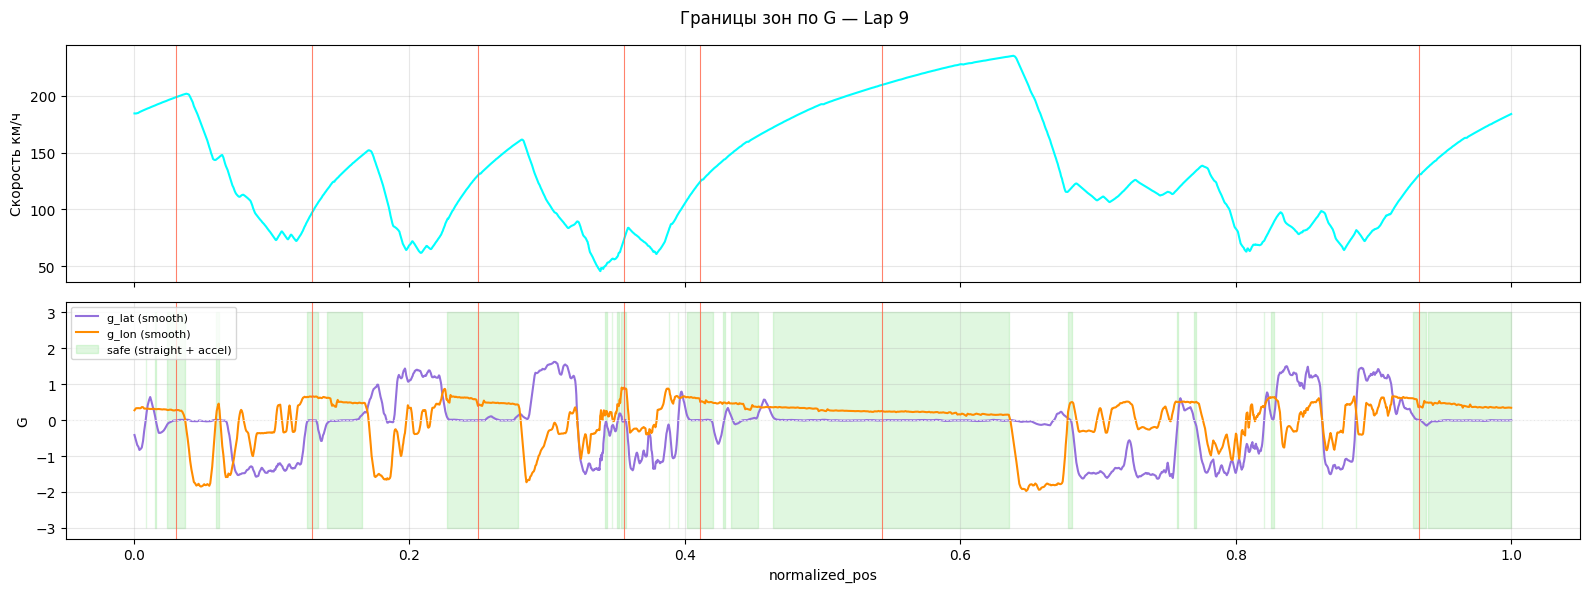

In [6]:
best_pos = best_lap_df['normalized_pos'].values

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(best_pos, best_lap_df['speed_kmh'], color='cyan')
axes[0].set_ylabel('Скорость км/ч')

axes[1].plot(best_pos, best_lat_smooth, color='mediumpurple', label='g_lat (smooth)')
axes[1].plot(best_pos, best_lon_smooth, color='darkorange', label='g_lon (smooth)')
axes[1].axhline(0, color='white', linewidth=0.5, linestyle='--')
axes[1].fill_between(best_pos, -3, 3, where=best_safe.values, color='limegreen', alpha=0.15, label='safe (straight + accel)')
axes[1].set_ylabel('G')
axes[1].set_xlabel('normalized_pos')
axes[1].legend(fontsize=8)

for ax in axes:
    for b in boundaries:
        ax.axvline(b, color='tomato', linewidth=0.8, alpha=0.8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Границы зон по G — Lap {best_lap}')
plt.tight_layout()
plt.show()

Те же границы, но на самой трассе (`car_x`/`car_z`) — так сразу видно, попадают ли они в повороты или реально стоят на прямых, без пересчёта через нормализованную позицию в голове.

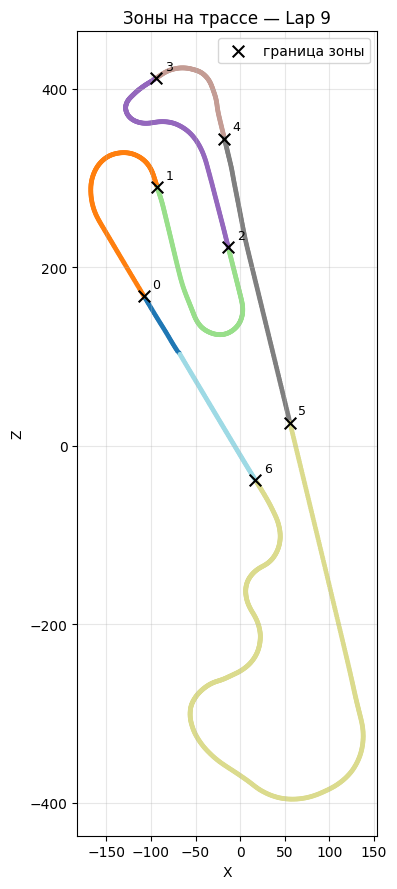

In [7]:
def nearest_rows(lap_df, positions):
    d = lap_df.sort_values('normalized_pos').reset_index(drop=True)
    idx = np.clip(d['normalized_pos'].searchsorted(positions), 0, len(d) - 1)
    return d.iloc[idx]


best_zones = np.searchsorted(sorted(boundaries), best_lap_df['normalized_pos'].values, side='right')
boundary_points = nearest_rows(best_lap_df, boundaries)

fig, ax = plt.subplots(figsize=(9, 9))
sc = ax.scatter(best_lap_df['car_x'], best_lap_df['car_z'], c=best_zones, cmap='tab20', s=6)
ax.scatter(boundary_points['car_x'], boundary_points['car_z'], color='black', marker='x', s=70, zorder=5, label='граница зоны')
for i, (_, row) in enumerate(boundary_points.iterrows()):
    ax.annotate(str(i), (row['car_x'], row['car_z']), textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.set_aspect('equal')
ax.set_xlabel('X'); ax.set_ylabel('Z')
ax.set_title(f'Зоны на трассе — Lap {best_lap}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Разметка всех кругов и sanity-check

Зоны не оборачиваются через финиш (0.99 → 0.0) — эта дуга физически одна, но во времени её ломает пополам сам счётчик кругов AC (конец одного круга / начало следующего). Поэтому крайние куски — это две отдельные граничные зоны, не одна.

Если сумма времён по зонам совпадает с реальным временем круга — разметка без дыр и наложений. Если нет — сигнал либо о баге, либо о проблеме в самих данных этого круга (и то и то полезно знать).

Отброшено мисклассифицированных строк на границах кругов: 6


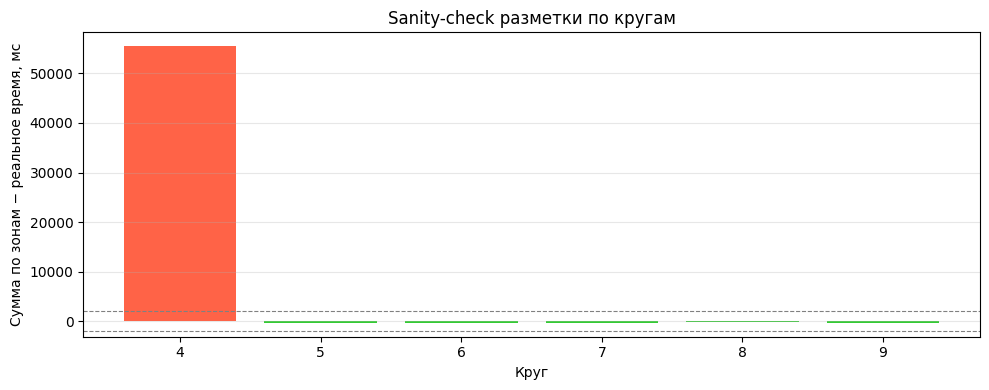

In [8]:
def assign_zones(pos, boundaries):
    b = sorted(boundaries)
    return np.searchsorted(b, pos, side='right')  # без оборота через 0/1 — крайние зоны не мержим


# AC обновляет completedLaps на один сэмпл позже, чем normalized_pos/lap_time —
# последняя строка круга физически уже относится к следующему кругу, но подписана старым
# номером. Без этой чистки зона у финиша ловит две несвязные по времени точки за круг.
clean = clean.sort_values(['lap', 'timestamp_ms']).reset_index(drop=True)
pos_vals = clean['normalized_pos'].values
lap_vals = clean['lap'].values
same_lap_prev = np.r_[False, lap_vals[1:] == lap_vals[:-1]]
boundary_dupe = same_lap_prev & (np.r_[0, np.diff(pos_vals)] < -0.5)
print(f"Отброшено мисклассифицированных строк на границах кругов: {boundary_dupe.sum()}")
clean = clean[~boundary_dupe].reset_index(drop=True)

clean['zone'] = assign_zones(clean['normalized_pos'].values, boundaries)

zone_times = (
    clean.groupby(['lap', 'zone'])['lap_time_ms']
    .agg(lambda s: s.max() - s.min())
    .unstack('zone')
)

compare = pd.DataFrame({
    'zones_sum_ms': zone_times.sum(axis=1),
    'actual_ms': lap_durations,
}).loc[valid_laps]
compare['diff_ms'] = compare['zones_sum_ms'] - compare['actual_ms']

SANE_THRESHOLD_MS = 2000
colors = ['tomato' if abs(v) >= SANE_THRESHOLD_MS else 'limegreen' for v in compare['diff_ms']]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(compare.index.astype(str), compare['diff_ms'], color=colors)
ax.axhline(SANE_THRESHOLD_MS, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(-SANE_THRESHOLD_MS, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Круг')
ax.set_ylabel('Сумма по зонам − реальное время, мс')
ax.set_title('Sanity-check разметки по кругам')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Зелёные круги (расхождение меньше пары сэмплов) проходят sanity-check, красные — нет, их разметке не доверяем ниже.

In [9]:
sane_laps = compare[compare['diff_ms'].abs() < SANE_THRESHOLD_MS].index.tolist()
print(f"Круги прошли sanity-check: {sane_laps}")
print(f"Отсеяны: {[l for l in valid_laps if l not in sane_laps]}")

Круги прошли sanity-check: [5, 6, 7, 8, 9]
Отсеяны: [4]


## 5. Где именно худший круг теряет время

Не тавтологичная проверка "лучший круг = больше очков" (это гарантировано алгеброй сложения по зонам), а то, в каких конкретно зонах у худшего (из прошедших sanity-check) круга накапливается отставание от лучшего из записанных времён в этой зоне.

Худший из чистых кругов: Lap 5  |  итоговый дефицит: 9183 мс


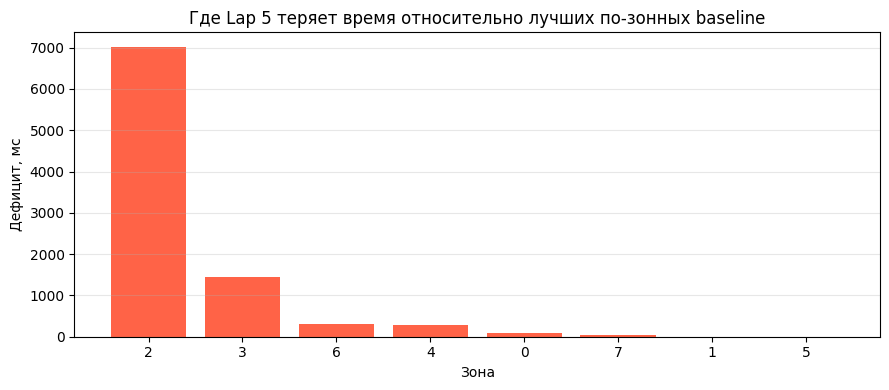

In [10]:
worst_sane_lap = int(compare.loc[sane_laps, 'actual_ms'].idxmax())

baseline = zone_times.loc[sane_laps].min()
deficit = (zone_times.loc[worst_sane_lap] - baseline).sort_values(ascending=False)

print(f"Худший из чистых кругов: Lap {worst_sane_lap}  |  итоговый дефицит: {deficit.sum():.0f} мс")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(deficit.index.astype(str), deficit.values, color='tomato')
ax.set_xlabel('Зона')
ax.set_ylabel('Дефицит, мс')
ax.set_title(f'Где Lap {worst_sane_lap} теряет время относительно лучших по-зонных baseline')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6. Лучший vs худший (из чистых) — на карте трассы

Линия — геометрия **лучшего** круга (`best_lap`), она тут просто как система координат (трасса одна и та же). Цвет и подписи показывают, где именно **худший из чистых** круг (`worst_sane_lap`) терял время относительно лучшего — не наоборот. Круг 4 сюда не берём — он не прошёл sanity-check (см. секцию 4), это брак записи, а не реальная езда.

In [ ]:
best_zone_times = zone_times.loc[best_lap]
worst_zone_times = zone_times.loc[worst_sane_lap]
lost_by_worst_s = (worst_zone_times - best_zone_times) / 1000  # сколько ХУДШИЙ круг проиграл в этой зоне

vmax = lost_by_worst_s.abs().max()

fig, ax = plt.subplots(figsize=(9, 10))
sc = ax.scatter(
    best_lap_df['car_x'], best_lap_df['car_z'],
    c=lost_by_worst_s.reindex(best_zones).values,
    cmap='RdYlGn_r', vmin=-vmax, vmax=vmax, s=10,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(f'Сколько Lap {worst_sane_lap} (худший) проиграл Lap {best_lap} (лучшему) здесь, сек')

for z in sorted(set(best_zones)):
    idx = np.where(best_zones == z)[0]
    mid_idx = idx[len(idx) // 2]
    row = best_lap_df.iloc[mid_idx]
    w, d = worst_zone_times[z] / 1000, lost_by_worst_s[z]
    verdict = "проиграл" if d > 0 else "выиграл"
    label = f"Lap {worst_sane_lap} {verdict} {abs(d):.1f}s"
    ax.annotate(
        label,
        (row['car_x'], row['car_z']),
        fontsize=8, ha='center',
        bbox=dict(boxstyle='round', fc='white', alpha=0.75, ec='none'),
    )

ax.set_aspect('equal')
ax.set_xlabel('X'); ax.set_ylabel('Z')
ax.set_title(f'Где Lap {worst_sane_lap} (худший) теряет/выигрывает время у Lap {best_lap} (лучшего)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Теоретический лучший круг — собираем из лучших кусков

Берём по каждой зоне лучшее время среди всех чистых кругов (`sane_laps`) и складываем — так делают в реальной телеметрии ("theoretical best lap"). Это не круг, который реально проехали, а потолок, если бы один заезд собрал все свои лучшие куски сразу.

На 5 кругах это ещё грубая оценка (та же история с популяцией, что обсуждали раньше) — но направление уже видно.

In [ ]:
sub = zone_times.loc[sane_laps]
theo_best_ms = sub.min(axis=0)
record_holder = sub.idxmin(axis=0)  # какой круг держит рекорд в каждой зоне

theo_total_s = theo_best_ms.sum() / 1000
actual_best_total_s = zone_times.loc[best_lap].sum() / 1000

print(f"Теоретический лучший круг (из кругов {sane_laps}): {theo_total_s:.3f}s")
print(f"Реальный лучший круг (Lap {best_lap}):              {actual_best_total_s:.3f}s")
print(f"На столе: {actual_best_total_s - theo_total_s:.3f}s — ни один реальный круг не собрал все свои лучшие куски сразу")
print(f"Держатели рекордов по зонам: {record_holder.to_dict()}")

Реальный лучший круг (Lap 9) против теоретического — по каждой зоне отдельно. Подпись над жёлтым столбиком — чей это кусок.

In [ ]:
zones_sorted = sorted(theo_best_ms.index)
x = np.arange(len(zones_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [theo_best_ms[z] / 1000 for z in zones_sorted], width, label='Теоретический лучший', color='gold')
ax.bar(x + width/2, [zone_times.loc[best_lap][z] / 1000 for z in zones_sorted], width, label=f'Lap {best_lap} (реальный лучший)', color='steelblue')

for i, z in enumerate(zones_sorted):
    ax.annotate(f"L{record_holder[z]}", (x[i] - width/2, theo_best_ms[z] / 1000), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([str(z) for z in zones_sorted])
ax.set_xlabel('Зона')
ax.set_ylabel('Время, сек')
ax.set_title('Теоретический лучший круг vs реальный лучший круг, по зонам')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

То же самое на карте трассы — чей кусок лучший в каждой зоне. Если бы одна зона стабильно принадлежала одному кругу — это было бы просто "у него был удачный круг"; вместо этого рекорды раскиданы по разным кругам, то есть проблема не "не повезло", а нет одного круга, который был бы одинаково хорош везде.

In [ ]:
holder_per_point = record_holder.reindex(best_zones).values.astype(int)
unique_holders = sorted(set(holder_per_point))
cmap = plt.get_cmap('tab10')
holder_color = {h: cmap(i) for i, h in enumerate(unique_holders)}
point_colors = [holder_color[h] for h in holder_per_point]

fig, ax = plt.subplots(figsize=(9, 10))
ax.scatter(best_lap_df['car_x'], best_lap_df['car_z'], c=point_colors, s=10)
for h in unique_holders:
    ax.scatter([], [], color=holder_color[h], label=f'Lap {h}')
ax.legend(title='Чей кусок лучший здесь')
ax.set_aspect('equal')
ax.set_xlabel('X'); ax.set_ylabel('Z')
ax.set_title('Какой круг держит рекорд в каждой зоне')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Стабильность vs пиковые куски

Lap 9 держит рекорд только в одной зоне (см. секцию 7), но выигрывает круг целиком. Смотрим, почему: раскладываем отставание каждого круга от теоретического лучшего по зонам — если один кусок отставания доминирует, это "не повезло в одном месте", если отставание размазано ровно — это и есть стабильность.

In [ ]:
gap_s = sub.subtract(theo_best_ms, axis=1) / 1000  # отставание каждого круга от теор. лучшего, по зонам
lap_order = gap_s.sum(axis=1).sort_values().index  # от лучшего к худшему по сумме

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(lap_order))
cmap = plt.get_cmap('tab10')
for i, z in enumerate(zones_sorted):
    vals = gap_s.loc[lap_order, z].values
    ax.bar([str(l) for l in lap_order], vals, bottom=bottom, color=cmap(i), label=f'zone {z}')
    bottom += vals

ax.set_xlabel('Круг (слева направо — от лучшего к худшему)')
ax.set_ylabel('Отставание от теоретического лучшего, сек')
ax.set_title('Из чего складывается отставание каждого круга')
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Максимальный "провал" в одной зоне на круг, сек:')
print(gap_s.max(axis=1).loc[lap_order].round(2))